<a href="https://colab.research.google.com/github/deep-l3arn3r/tutorials/blob/nlp_with_transformers/financial_tweet_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Load Datasets**

In [ ]:
import os
from huggingface_hub import login

# Set it manually in code (won’t persist between sessions)
os.environ["HF_TOKEN"] = ""

# Now login
login(token=os.environ["HF_TOKEN"])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [ ]:
!pip install -U fsspec
!pip install datasets==2.14.5

  Using cached fsspec-2025.5.1-py3-none-any.whl.metadata (11 kB)
Using cached fsspec-2025.5.1-py3-none-any.whl (199 kB)
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2023.6.0
    Uninstalling fsspec-2023.6.0:
      Successfully uninstalled fsspec-2023.6.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 2.14.5 requires fsspec[http]<2023.9.0,>=2023.1.0, but you have fsspec 2025.5.1 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12==12.4.127; p

In [ ]:
from datasets import load_dataset

financial = load_dataset("zeroshot/twitter-financial-news-sentiment")

**Data Exploration**

In [ ]:
financial

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9543
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2388
    })
})

In [ ]:
train_ds = financial["train"]
train_ds[:5]

{'text': ['$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT',
  '$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3',
  '$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb',
  '$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N',
  '$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB'],
 'label': [0, 0, 0, 0, 0]}

**From Datasets to DataFrames**

In [ ]:
import pandas as pd

train_ds.set_format("pandas")
train_df = train_ds[:]
train_df

,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0
...,...,...
9538,The Week's Gainers and Losers on the Stoxx Eur...,2
9539,Tupperware Brands among consumer gainers; Unil...,2
9540,vTv Therapeutics leads healthcare gainers; Myo...,2
9541,"WORK, XPO, PYX and AMKR among after hour movers",2


**Class Distribution**

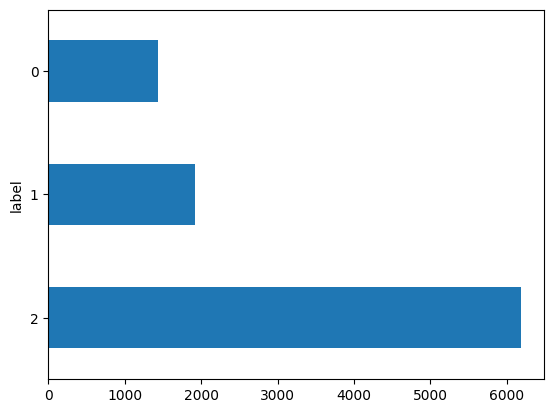

In [ ]:
import matplotlib.pyplot as plt

train_df["label"].value_counts().plot.barh()
plt.show()

In [ ]:
train_df["Words"] = train_df["text"].str.split().apply(len)
train_df.groupby("label")["Words"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,1442.0,12.000693,4.306846,3.0,9.0,11.0,15.0,32.0
1,1923.0,11.926157,4.317975,2.0,9.0,11.0,14.0,29.0
2,6178.0,12.298317,4.843131,1.0,9.0,12.0,16.0,29.0


In [ ]:
train_ds.reset_format()

**Subword Tokenization**

In [ ]:
MODEL = "distilbert-base-uncased"
TEXT = "Well, what a beautiful day to purchase stockers today."

In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL)

In [ ]:
encoded_text = tokenizer(TEXT)
print(encoded_text)

{'input_ids': [101, 2092, 1010, 2054, 1037, 3376, 2154, 2000, 5309, 4518, 2545, 2651, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [ ]:
tokens = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)
print(tokens)

['[CLS]', 'well', ',', 'what', 'a', 'beautiful', 'day', 'to', 'purchase', 'stock', '##ers', 'today', '.', '[SEP]']


In [ ]:
print(tokenizer.convert_tokens_to_string(tokens))

[CLS] well, what a beautiful day to purchase stockers today. [SEP]


In [ ]:
tokenizer.model_max_length, tokenizer.vocab_size

(512, 30522)

**Tokenizing Entire Dataset**

In [ ]:
def tokenize(batch):
  return tokenizer(batch["text"], padding=True, truncation=True)

In [ ]:
print(tokenize(financial["train"][:2]))

{'input_ids': [[101, 1002, 2011, 4859, 1011, 16545, 5302, 16998, 15934, 2015, 1999, 10908, 2006, 3458, 6240, 16770, 1024, 1013, 1013, 1056, 1012, 2522, 1013, 1038, 2094, 2692, 2595, 29292, 2290, 15992, 2102, 102, 0, 0, 0, 0], [101, 1002, 10507, 2140, 1002, 22110, 2140, 1011, 2053, 16069, 2685, 2000, 21725, 2015, 11251, 2012, 11485, 1998, 2548, 7139, 16770, 1024, 1013, 1013, 1056, 1012, 2522, 1013, 1061, 2290, 3501, 13876, 2475, 5596, 2509, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


In [ ]:
special_tokens = sorted(list(zip(tokenizer.all_special_tokens, tokenizer.all_special_ids)), key=lambda x: x[1])
special_tokens

[('[PAD]', 0), ('[UNK]', 100), ('[CLS]', 101), ('[SEP]', 102), ('[MASK]', 103)]

In [ ]:
financial_encoded = financial.map(tokenize, batched=True, batch_size=None)

**Training a Text Classifier**

**Using Pre-trained weights**

In [ ]:
import torch
from transformers import AutoModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModel.from_pretrained(MODEL).to(device)

In [ ]:
inputs = tokenizer(TEXT, return_tensors="pt").to(device)
print(inputs['input_ids'].size())
inputs = {k:v.to(device) for k,v in inputs.items()}
inputs

torch.Size([1, 14])


{'input_ids': tensor([[ 101, 2092, 1010, 2054, 1037, 3376, 2154, 2000, 5309, 4518, 2545, 2651,
          1012,  102]], device='cuda:0'),
 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')}

In [ ]:
with torch.no_grad():
  outputs = model(**inputs)

print(outputs)

BaseModelOutput(last_hidden_state=tensor([[[ 0.0373, -0.0082,  0.0495,  ..., -0.0388,  0.3183,  0.1646],
         [ 0.4876,  0.2396,  0.1248,  ...,  0.1562,  0.6663, -0.2639],
         [-0.1082,  0.3751,  0.4645,  ..., -0.3073,  0.2043, -0.0461],
         ...,
         [-0.1224,  0.0589, -0.0686,  ..., -0.3898,  0.1018, -0.6773],
         [ 0.6185,  0.0126, -0.4240,  ...,  0.3708, -0.3237, -0.5568],
         [ 0.5148,  0.2404,  0.1822,  ...,  0.2693, -0.1362, -0.4000]]],
       device='cuda:0'), hidden_states=None, attentions=None)


In [ ]:
outputs.last_hidden_state.size()

torch.Size([1, 14, 768])

**Hidden States -> Batch Format**

In [ ]:
def extract_hidden_states(batch):
  ## Moves to device and batchify. Along with only those inputs that are valid for model
  inputs = {k:v.to(device) for k, v in batch.items() if k in tokenizer.model_input_names}


  with torch.no_grad():
    last_hidden_state = model(**inputs).last_hidden_state

  return {"hidden_state": last_hidden_state[:, 0].cpu().numpy()}

In [ ]:
financial_encoded.set_format("torch", columns=['input_ids', 'attention_mask', 'label'])

In [ ]:
!pip install numpy==1.26.4

In [ ]:
financial_hidden = financial_encoded.map(extract_hidden_states, batched=True)

Map:   0%|          | 0/9543 [00:00<?, ? examples/s]

Map:   0%|          | 0/2388 [00:00<?, ? examples/s]

**Train Val Split**

In [ ]:
X_train = financial_hidden["train"]["hidden_state"]
y_train = financial_hidden["train"]["label"]

X_val = financial_hidden["validation"]["hidden_state"]
y_val = financial_hidden["validation"]["label"]

In [ ]:
X_train.shape, X_val.shape

(torch.Size([9543, 768]), torch.Size([2388, 768]))

**Visualization**

In [ ]:
from umap import UMAP
import seaborn as sns

reducer = UMAP(n_components=2, metric="cosine", random_state=42)
embedding = reducer.fit_transform(X_train)

<Axes: xlabel='x', ylabel='y'>

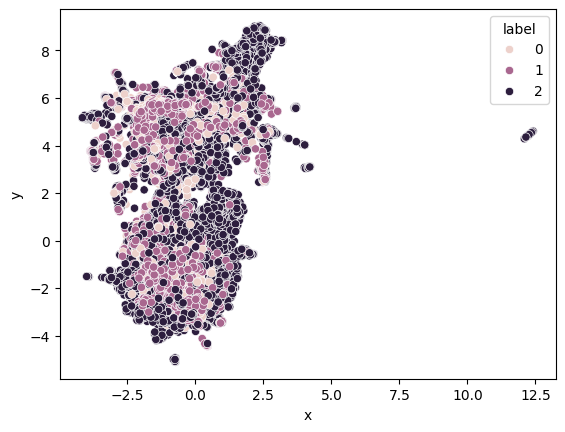

In [ ]:
df_emb = pd.DataFrame({"x": embedding[:, 0], "y": embedding[:, 1], "label": y_train})
sns.scatterplot(data=df_emb, x="x", y="y", hue="label", legend="full")

**Training an LR**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_clf_1 = LogisticRegression(class_weight="balanced")
lr_clf_1.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [ ]:
lr_clf_2 = LogisticRegression()
lr_clf_2.fit(X_train, y_train)

LogisticRegression()

In [ ]:
lr_clf_1.score(X_val, y_val), lr_clf_2.score(X_val, y_val)

(0.7546063651591289, 0.8077889447236181)

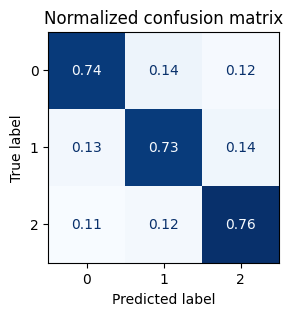

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
y_preds = lr_clf_1.predict(X_val)
y_true = y_val
fig, ax = plt.subplots(figsize=(3, 3))
cm = confusion_matrix(y_true, y_preds, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1", "2"])
disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
plt.title("Normalized confusion matrix")
plt.show()

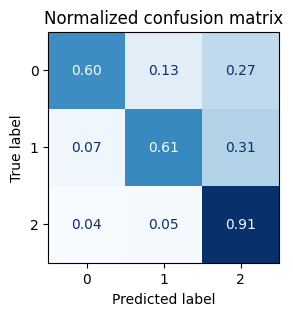

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
y_preds = lr_clf_2.predict(X_val)
y_true = y_val
fig, ax = plt.subplots(figsize=(3, 3))
cm = confusion_matrix(y_true, y_preds, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1", "2"])
disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
plt.title("Normalized confusion matrix")
plt.show()

**Loading Pre-trained Model**

In [ ]:
from transformers import AutoModelForSequenceClassification

num_labels = 3
model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=num_labels).to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1_score = 1
  acc = accuracy_score(labels, preds)

  return {"accuracy":acc, "f1": f1_score}

**Training the Model**

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
from transformers import Trainer, TrainingArguments

BATCH_SIZE = 64
logging_steps = len(financial_encoded["train"]) // BATCH_SIZE

model_name = f"{MODEL}-finetuned-financial-tweet"

In [ ]:
training_args = TrainingArguments(
                output_dir=model_name,
                eval_strategy="epoch",
                num_train_epochs=1,
                learning_rate=2e-5,
                run_name="my-awesome-run",
                report_to="none",
                per_device_train_batch_size=BATCH_SIZE,
                per_device_eval_batch_size=BATCH_SIZE,
                disable_tqdm=False,
                logging_steps=logging_steps,
                push_to_hub=False,
                log_level="error"
                )

In [ ]:
import transformers
print(transformers.__version__)  # Should be >= 4.0 (ideally 4.30+)


4.53.1


In [ ]:
trainer = Trainer(model=model, args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset=financial_encoded["train"],
                  eval_dataset=financial_encoded["validation"],
                  tokenizer=tokenizer)

trainer.train();

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.239000,0.365098,0.867253,1


In [ ]:
preds_output = trainer.predict(financial_encoded["validation"])
preds_output.metrics

{'test_loss': 0.3650975525379181,
 'test_accuracy': 0.8672529313232831,
 'test_f1': 1,
 'test_runtime': 4.7894,
 'test_samples_per_second': 498.6,
 'test_steps_per_second': 7.934}

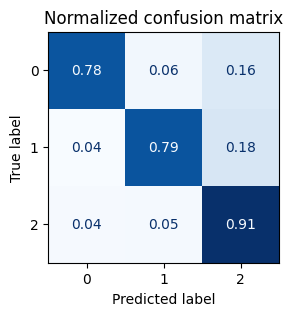

In [ ]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
y_preds = np.argmax(preds_output.predictions, axis=1)
y_true = y_val
fig, ax = plt.subplots(figsize=(3, 3))
cm = confusion_matrix(y_true, y_preds, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1", "2"])
disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
plt.title("Normalized confusion matrix")
plt.show()

**Error Analysis**

In [ ]:
from torch.nn.functional import cross_entropy

def forward_pass_with_labels(batch):
  inputs = {k:v.to(device) for k, v in batch.items() if k in tokenizer.model_input_names}
  labels = batch["label"].to(device)

  with torch.no_grad():
    outputs = model(**inputs)
    pred_label = torch.argmax(outputs.logits, axis=-1)


  logits = outputs.logits
  loss = cross_entropy(logits, labels, reduction="none")

  return {"loss": loss.cpu().numpy(), "predicted_label": pred_label.cpu().numpy()}

In [ ]:
financial_hidden["validation"] = financial_hidden["validation"].map(forward_pass_with_labels, batched=True)

Map:   0%|          | 0/2388 [00:00<?, ? examples/s]

In [ ]:
financial_hidden.set_format("pandas")
cols = ["text", "label", "predicted_label", "loss"]
df_test = financial_hidden["validation"][:][cols]

In [ ]:
df_test.sort_values("loss", ascending=False).head(10)

,text,label,predicted_label,loss
972,"Turkish banks refuse to lend to Istanbul, hey ...",0,2,6.103030
504,Press release: cyber attack - update January 3...,0,2,5.789450
801,Bipartisan Group Of US Lawmakers Introduce Bil...,1,2,5.721919
217,5 Reasons To Love Wendy's On Its 50th Birthday,1,2,5.554465
959,Every Bubble Eventually Finds Its Pin https://...,0,2,5.517694
877,Ã‚Â Chegg Reports 2019 Financial Results and R...,1,2,5.473086
231,NVIDIA : GPU-Powered Semi Simulation Snags Cov...,1,2,5.377944
1469,HSBC makes last-minute settlement with ex-curr...,1,2,4.886175
1592,US Proved Oil & Gas Reserves Hit New Record High,0,1,4.785086
112,"No, The Fed Won't ""Save The Market"" - Here's W...",0,2,4.767030


In [ ]:
df_test.sort_values("loss", ascending=True).head(10)

,text,label,predicted_label,loss
1020,✅Get the best deals. \n✅Don't break the bank. ...,2,2,0.004746
308,Ashley House : 10th December 2019 - Annual Gen...,2,2,0.004869
674,ChoiceOne Financial Services reports Q4 results,2,2,0.004926
735,Quinsam Capital reports Q3 results,2,2,0.004946
819,LHN : Moscow Exchange to launch natural gas fu...,2,2,0.004954
748,West End Indiana Bancshares : 3rd Quarter 2019...,2,2,0.004964
723,Northeast Community Bancorp reports Q4 results,2,2,0.004982
666,Bank Hapoalim reports Q3 results,2,2,0.005057
1254,One Conscious Objector. Follow this and any ot...,2,2,0.005170
725,Novoheart Holdings reports Q1 results,2,2,0.005171


In [73]:
!pip install nb-clean
!nb-clean clean  financial_tweet_sentiment.ipynb


In [75]:
!pip install nbformat
import nbformat

# Load the notebook
notebook_path = "financial_tweet_sentiment.ipynb"  # change this
nb = nbformat.read(notebook_path, as_version=nbformat.NO_CONVERT)

# Fix metadata.widgets
if "widgets" in nb["metadata"]:
    if "application/vnd.jupyter.widget-state+json" in nb["metadata"]["widgets"]:
        nb["metadata"]["widgets"]["application/vnd.jupyter.widget-state+json"]["state"] = {}

# Save the fixed notebook
nbformat.write(nb, notebook_path)
print("✅ Notebook patched successfully!")


✅ Notebook patched successfully!
